In [107]:
!pip install transformers



In [108]:
!pip install -q -U watermark


In [109]:
%reload_ext watermark
%watermark -v -p numpy,pandas,torch,transformers

Python implementation: CPython
Python version       : 3.8.8
IPython version      : 7.22.0

numpy       : 1.20.1
pandas      : 1.2.4
torch       : 1.12.0
transformers: 4.20.1



In [110]:
import transformers
from transformers import XLNetTokenizer, XLNetModel, AdamW, get_linear_schedule_with_warmup
import torch

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import defaultdict
from textwrap import wrap
from pylab import rcParams

from torch import nn, optim
from keras_preprocessing.sequence import pad_sequences
from torch.utils.data import TensorDataset,RandomSampler,SequentialSampler
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

In [111]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]

sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [112]:
df = pd.read_csv("ILDC_single.csv")
df.head()

,text,label,split,name
0,"F. NARIMAN, J. Leave granted. In 2008, the Pu...",1,train,2019_890.txt
1,"S. THAKUR, J. Leave granted. These appeals ar...",0,train,2014_170.txt
2,"Markandey Katju, J. Leave granted. Heard lear...",1,train,2010_721.txt
3,"ALTAMAS KABIR,J. Leave granted. The question ...",1,train,2008_1460.txt
4,"CIVIL APPEAL NO. 598 OF 2007 K. MATHUR, J. Th...",1,train,2008_188.txt


In [113]:
df.drop(df.columns[[2,3]], axis=1, inplace=True)
df.head()

,text,label
0,"F. NARIMAN, J. Leave granted. In 2008, the Pu...",1
1,"S. THAKUR, J. Leave granted. These appeals ar...",0
2,"Markandey Katju, J. Leave granted. Heard lear...",1
3,"ALTAMAS KABIR,J. Leave granted. The question ...",1
4,"CIVIL APPEAL NO. 598 OF 2007 K. MATHUR, J. Th...",1


In [114]:
df=df[0:24]

C:\Users\punee\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


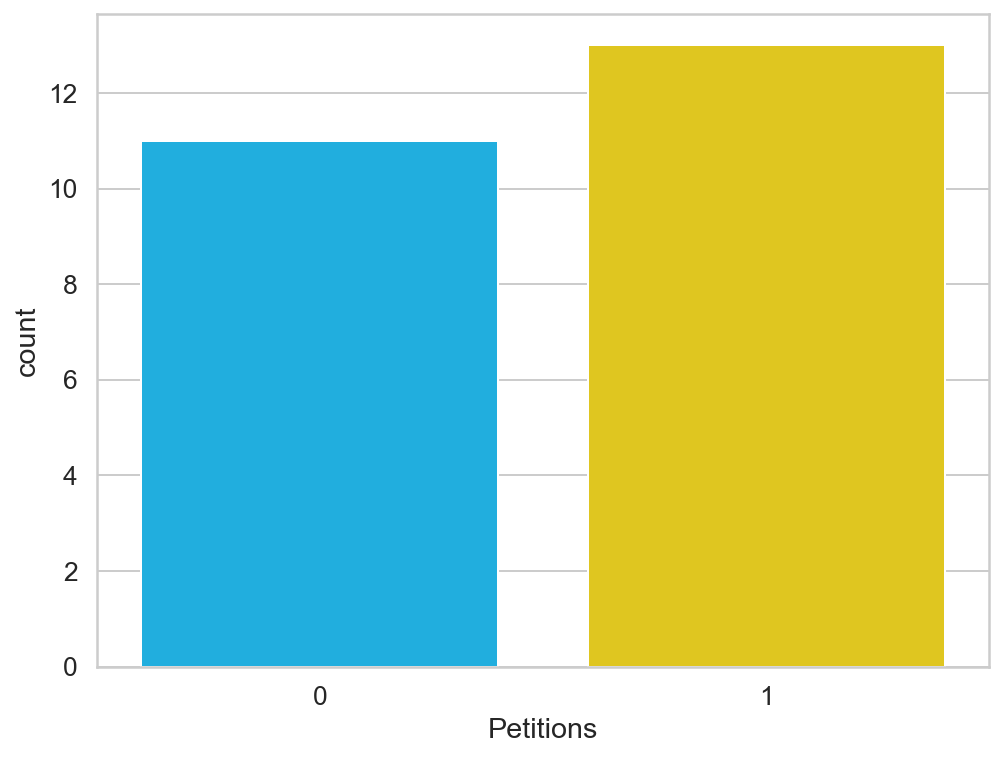

In [115]:
rcParams['figure.figsize'] = 8, 6
sns.countplot(df.label)
plt.xlabel('Petitions');

In [116]:
df["label"].value_counts()

1    13
0    11
Name: label, dtype: int64

In [117]:
from transformers import XLNetTokenizer, XLNetModel
PRE_TRAINED_MODEL_NAME = 'xlnet-base-cased'
tokenizer = XLNetTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

In [118]:
#example sample

In [119]:
input_txt = "India is my country. All Indians are my brothers and sisters"
encodings = tokenizer.encode_plus(input_txt, add_special_tokens=True, max_length=16, return_tensors='pt', return_token_type_ids=False, return_attention_mask=True, pad_to_max_length=False)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


In [120]:
print('input_ids : ',encodings['input_ids'])

input_ids :  tensor([[ 837,   27,   94,  234,    9,  394, 7056,   41,   94, 4194,   21, 8301,
            4,    3]])


In [121]:
tokenizer.convert_ids_to_tokens(encodings['input_ids'][0])

['▁India',
 '▁is',
 '▁my',
 '▁country',
 '.',
 '▁All',
 '▁Indians',
 '▁are',
 '▁my',
 '▁brothers',
 '▁and',
 '▁sisters',
 '<sep>',
 '<cls>']

In [122]:
type(encodings['attention_mask'])

torch.Tensor

In [123]:
attention_mask = pad_sequences(encodings['attention_mask'], maxlen=512, dtype=torch.Tensor ,truncating="post",padding="post")

In [124]:
attention_mask = attention_mask.astype(dtype = 'int64')
attention_mask = torch.tensor(attention_mask) 
attention_mask.flatten()

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [125]:
encodings['input_ids']

tensor([[ 837,   27,   94,  234,    9,  394, 7056,   41,   94, 4194,   21, 8301,
            4,    3]])

In [126]:
token_lens = []

for txt in df['text']:
  tokens = tokenizer.encode(txt, max_length=2048)
  token_lens.append(len(tokens))

In [127]:
class ImdbDataset(Dataset):

    def __init__(self, text, targets, tokenizer, max_len):
        self.text = text
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.text)
    
    def __getitem__(self, item):
        text = str(self.text[item])
        target = self.targets[item]

        encoding = self.tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=self.max_len,
        return_token_type_ids=False,
        pad_to_max_length=False,
        return_attention_mask=True,
        return_tensors='pt',
        )

        input_ids = pad_sequences(encoding['input_ids'], maxlen=MAX_LEN, dtype=torch.Tensor ,truncating="post",padding="post")
        input_ids = input_ids.astype(dtype = 'int64')
        input_ids = torch.tensor(input_ids) 

        attention_mask = pad_sequences(encoding['attention_mask'], maxlen=MAX_LEN, dtype=torch.Tensor ,truncating="post",padding="post")
        attention_mask = attention_mask.astype(dtype = 'int64')
        attention_mask = torch.tensor(attention_mask)       

        return {
        'text_text': text,
        'input_ids': input_ids,
        'attention_mask': attention_mask.flatten(),
        'targets': torch.tensor(target, dtype=torch.long)
        }

In [128]:
df_train, df_test = train_test_split(df, test_size=0.5, random_state=101)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=101)

In [129]:
df_train.shape, df_val.shape, df_test.shape

((12, 2), (6, 2), (6, 2))

In [130]:
def create_data_loader(df, tokenizer, max_len, batch_size):
  ds = ImdbDataset(
    text=df.text.to_numpy(),
    targets=df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )

  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=0
  )

In [131]:
MAX_LEN = 512

In [132]:
BATCH_SIZE = 2

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

In [133]:
print(val_data_loader)

In [134]:
!pip install tokenizer

In [135]:
!pip install sentencepiece

In [136]:
from transformers import XLNetForSequenceClassification
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased', num_labels = 2)
model = model.to(device)

Some weights of the model checkpoint at xlnet-base-cased were not used when initializing XLNetForSequenceClassification: ['lm_loss.bias', 'lm_loss.weight']
- This IS expected if you are initializing XLNetForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLNetForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.weight', 'sequence_summary.summary.weight', 'sequence_summary.summary.bias', 'logits_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions a

In [137]:
model

XLNetForSequenceClassification(
  (transformer): XLNetModel(
    (word_embedding): Embedding(32000, 768)
    (layer): ModuleList(
      (0): XLNetLayer(
        (rel_attn): XLNetRelativeAttention(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): XLNetFeedForward(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (layer_1): Linear(in_features=768, out_features=3072, bias=True)
          (layer_2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation_function): GELUActivation()
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): XLNetLayer(
        (rel_attn): XLNetRelativeAttention(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): XLNetFeedForward

In [138]:
EPOCHS = 3

param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
                                {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
                                {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)], 'weight_decay':0.0}
]
optimizer = AdamW(optimizer_grouped_parameters, lr=3e-5)

total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

C:\Users\punee\anaconda3\lib\site-packages\transformers\optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [139]:
data = next(iter(val_data_loader))
data.keys()

dict_keys(['text_text', 'input_ids', 'attention_mask', 'targets'])

In [140]:
input_ids = data['input_ids'].to(device)
attention_mask = data['attention_mask'].to(device)
targets = data['targets'].to(device)
print(input_ids.reshape(2,512).shape) # batch size x seq length
print(attention_mask.shape) # batch size x seq length

torch.Size([2, 512])
torch.Size([2, 512])


In [141]:
input_ids[0]

tensor([[   17,    83,     9,    17,  7737, 14142, 10099,    19,   586,     9,
         13531,  3445,     9,   592,  7864,    41,  2324,   157,    48,   374,
          9460,   664,   138,   487,    19,  1327,  1400,    37,    18,  1254,
          1045,    20,  4382,    66,  4969,  3541,    19, 27411, 14064,    38,
         24696, 16656,    18,  1254,  1045,    51,   257,  3968,    18,   374,
          1400,    37,    18,   438,  2915,  1841,   677,  3348, 18568,    25,
            17, 17602,   336,     9,  4539,  3489,    20,  2226,    22,    18,
          4349,    18,   219,  3028,    18,  5424,    20,    52,  1045,    25,
          1024,     9, 15864,  8460, 17579, 16518,    21,  1137,    23,     9,
          2721,     9,   438,    20, 27411, 14064,    21,  1137,    23,     9,
          1778,   241,    17,    83,  4072, 19796,    19,    22,    39, 11609,
            25,    81,  1479,     9,   460,   374,  9460,   198,  1937,   704,
            19,  1077,  1400,    37,    18,  1254,  

In [142]:
outputs = model(input_ids.reshape(2,512), token_type_ids=None, attention_mask=attention_mask, labels=targets)
outputs

XLNetForSequenceClassificationOutput(loss=tensor(0.5031, grad_fn=<NllLossBackward0>), logits=tensor([[ 0.1779, -0.1551],
        [ 0.2295, -0.2925]], grad_fn=<AddmmBackward0>), mems=(tensor([[[-0.0387, -0.0099, -0.0053,  ...,  0.0643,  0.0192, -0.0144],
         [ 0.0127, -0.0260, -0.0200,  ...,  0.0548, -0.0664,  0.0132]],

        [[-0.0038, -0.0337,  0.0515,  ...,  0.0109,  0.0225,  0.0556],
         [-0.0347, -0.0632,  0.0088,  ..., -0.0184, -0.0528,  0.0199]],

        [[-0.0238, -0.0061, -0.0163,  ..., -0.0160,  0.0431, -0.0309],
         [-0.0211, -0.0247, -0.0122,  ..., -0.0107,  0.0340, -0.0201]],

        ...,

        [[-0.0200, -0.0444,  0.0044,  ...,  0.0117,  0.0014,  0.0473],
         [ 0.0222,  0.0560,  0.0465,  ..., -0.0527,  0.0118,  0.1189]],

        [[ 0.0788, -0.0583, -0.0905,  ...,  0.0493,  0.0634, -0.0520],
         [ 0.0788, -0.0583, -0.0905,  ...,  0.0493,  0.0634, -0.0520]],

        [[ 0.0181, -0.0015, -0.1494,  ...,  0.0012, -0.0009,  0.0188],
         [ 0

In [143]:
type(outputs[0])

torch.Tensor

In [144]:
def train_epoch(model, data_loader, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    acc = 0
    counter = 0
  
    for d in data_loader:
        input_ids = d["input_ids"].reshape(2,512).to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["targets"].to(device)
        
        outputs = model(input_ids=input_ids, token_type_ids=None, attention_mask=attention_mask, labels = targets)
        loss = outputs[0]
        logits = outputs[1]

        # preds = preds.cpu().detach().numpy()
        _, prediction = torch.max(outputs[1], dim=1)
        targets = targets.cpu().detach().numpy()
        prediction = prediction.cpu().detach().numpy()
        accuracy = metrics.accuracy_score(targets, prediction)

        acc += accuracy
        losses.append(loss.item())
        
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        counter = counter + 1

    return acc / counter, np.mean(losses)

In [145]:
def eval_model(model, data_loader, device, n_examples):
    model = model.eval()
    losses = []
    acc = 0
    counter = 0
  
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].reshape(2,512).to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)
            
            outputs = model(input_ids=input_ids, token_type_ids=None, attention_mask=attention_mask, labels = targets)
            loss = outputs[0]
            logits = outputs[1]

            _, prediction = torch.max(outputs[1], dim=1)
            targets = targets.cpu().detach().numpy()
            prediction = prediction.cpu().detach().numpy()
            accuracy = metrics.accuracy_score(targets, prediction)

            acc += accuracy
            losses.append(loss.item())
            counter += 1

    return acc / counter, np.mean(losses)

In [146]:
import sklearn.metrics as metrics

In [147]:
%%time
history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)

    train_acc, train_loss = train_epoch(
        model,
        train_data_loader,     
        optimizer, 
        device, 
        scheduler, 
        len(df_train)
    )

    print(f'Train loss {train_loss} Train accuracy {train_acc}')

    val_acc, val_loss = eval_model(
        model,
        val_data_loader, 
        device, 
        len(df_val)
    )

    print(f'Val loss {val_loss} Val accuracy {val_acc}')
    print()

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)

    if val_acc > best_accuracy:
        torch.save(model.state_dict(), "Xlnetmodel")
        best_accuracy = val_acc

Epoch 1/3
----------
Train loss 0.8514639139175415 Train accuracy 0.5
Val loss 0.703880618015925 Val accuracy 0.6666666666666666

Epoch 2/3
----------
Train loss 0.6337158928314844 Train accuracy 0.6666666666666666
Val loss 0.6571313540140787 Val accuracy 0.6666666666666666

Epoch 3/3
----------
Train loss 0.5091020613908768 Train accuracy 0.9166666666666666
Val loss 0.6048691868782043 Val accuracy 0.8333333333333334

Wall time: 8min 9s


In [148]:
model.load_state_dict(torch.load("Xlnetmodel"))

<All keys matched successfully>

In [149]:
model = model.to(device)

In [150]:
test_acc, test_loss = eval_model(
  model,
  test_data_loader,
  device,
  len(df_test)
)

print('Test Accuracy :', test_acc)
print('Test Loss :', test_loss)

Test Accuracy : 0.5
Test Loss : 0.7180929382642111


In [155]:
def get_predictions(model, data_loader):
    model = model.eval()
    
    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:

            texts = d["text_text"]
            input_ids = d["input_ids"].reshape(2,512).to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)
            
            outputs = model(input_ids=input_ids, token_type_ids=None, attention_mask=attention_mask, labels = targets)

            loss = outputs[0]
            logits = outputs[1]
            
            _, preds = torch.max(outputs[1], dim=1)

            probs = F.softmax(outputs[1], dim=1)

            review_texts.extend(texts)
            predictions.extend(preds)
            prediction_probs.extend(probs)
            real_values.extend(targets)

    predictions = torch.stack(predictions).cpu()
    prediction_probs = torch.stack(prediction_probs).cpu()
    real_values = torch.stack(real_values).cpu()
    return review_texts, predictions, prediction_probs, real_values

In [156]:
y_text, y_pred, y_pred_probs, y_test = get_predictions(
  model,
  test_data_loader
)


In [158]:
class_names=["rejected","accepted"]

In [159]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    rejected       0.50      0.67      0.57         3
    accepted       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



In [166]:
from sklearn.metrics import confusion_matrix

In [167]:
confusion_matrix(y_test, y_pred)

array([[2, 1],
       [2, 1]], dtype=int64)

In [164]:
def predict_sentiment(text):
    review_text = text

    encoded_review = tokenizer.encode_plus(
    review_text,
    max_length=MAX_LEN,
    add_special_tokens=True,
    return_token_type_ids=False,
    pad_to_max_length=False,
    return_attention_mask=True,
    return_tensors='pt',
    )

    input_ids = pad_sequences(encoded_review['input_ids'], maxlen=MAX_LEN, dtype=torch.Tensor ,truncating="post",padding="post")
    input_ids = input_ids.astype(dtype = 'int64')
    input_ids = torch.tensor(input_ids) 

    attention_mask = pad_sequences(encoded_review['attention_mask'], maxlen=MAX_LEN, dtype=torch.Tensor ,truncating="post",padding="post")
    attention_mask = attention_mask.astype(dtype = 'int64')
    attention_mask = torch.tensor(attention_mask) 

    input_ids = input_ids.reshape(1,512).to(device)
    attention_mask = attention_mask.to(device)

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    outputs = outputs[0][0].cpu().detach()

    probs = F.softmax(outputs, dim=-1).cpu().detach().numpy().tolist()
    _, prediction = torch.max(outputs, dim =-1)

    print("Petition accepted:", probs[1])
    print("petition rejected:", probs[0])
    #print(f'Review text: {review_text}')
    print(f'Sentiment  : {class_names[prediction]}')

In [165]:
text = "The appellant on February 9, 1961 was appointed as an Officer in Grade III in the respondent Bank ( for short 'the Bank'). He was promoted on April 1, 1968 to the Grade officer in the Foreign Exchange Department in the Head Office of the Bank. Sometime in 1964, MCH Society ( for short 'the Society') was formed of which the appellant was one of the chief promoters and thereafter its Secretary. The object of the Society was to construct residential premises for the employees of the Bank and its other members. It appears that the complaint was received in respect of the affairs of the Society relating to misappropriation of the funds of the Society and consequently, in exercise of the powers under Section S of Act A1, the Registrar on April 23, 1969 instituted an inquiry thereof. P1 was appointed the Registrar's nominee who on October 4, 1969; submitted the report holding the appellant and two other office bearers of the Society negligent in dealing with the funds of the Society causing a loss to the tune of Rs. 3,59,000/-. The Registrar on October 21, 1969, passed an order appointing an officer under Section S of A1 to assess the loss caused to the Society. However, the Government by its order dated November 29, 1969 annulled the Registrar's order dated April 23, 1969 and October 21, 1969 and directed a fresh inquiry into the affairs of the Society. On December 17, 1969, the Bank issued show cause notice to the appellant to explain within fifteen days his alleged negligent conduct in dealing with the affairs of the Society as revealed in the report dated 4th October, 1969. In the meantime, P2 came to be appointed by the Registrar vide his order dated 26th July, 1969, to make inquiries under Section S of A1. Petitioner by his reply dated 18/22th January, 1970 submitted his explanation and also challenged the legality of the inquiry and the findings recorded therein. On 5th March, 1970, P3, treasurer of the Society and an employee of the Bank criminal complaints in the Court of Addl. Chief Presidency Magistrate  alleging that the appellant and two other office bearers of the society had dishonestly misappropriated a sum of Rs. 51,000/ and Rs. 80,000/- respectively which was entrusted to the appellant in his capacity as Promoter and Secretary of the Society and thereby committed criminal breach of trust. The Magistrate framed the charges against the appellant. The Bank having regard to the serious misconduct of the appellant involving moral turpitude vide its order dated 3rd November, 1970 suspended the appellant pending trial. The appellant protested this action of the Bank complaining that he was not given an opportunity of hearing before passing the order of suspension. In the meantime, P2, the authorized officer appointed by the Registrar vide his order dated 9th October, 1971 held the appellant liable to pay Rs. 2,36,000/- to the Society in addition to the amount of Rs. 2,03,000/- for which he (the appellant) and two other office bearers of the Society were held jointly liable. The Bank in view of this finding, vide its order dated 29th November, 1971 terminated the services of the appellant with effect from 1st December, 1971 along with notice pay. The appellant protested against the Action of the Bank and on 3rd December, 1971 filed detailed representation against the order of termination. The Bank replied to the appellant's representation and justified its action. The appellant on 28th December, 1971 submitted his reply to the Bank stating, inter alia, that the termination of his services was not simplicitor and was in violation of the principles of natural justice; that no opportunity of hearing was given to him; that the termination order attached stigma. The appellant aggrieved by the findings and order made by P2 appealed before Tribunal. In the meantime, the criminal proceedings ended in conviction vide order dated 27th March, 1972 passed by the Addl. Chief Metropolitan Magistrate. The appellant challenged the order of conviction and sentence in the High Court  and during the pendency of the said appeal, the Tribunal vide its order dated April 12, 1973 dismissed the appellant's appeal but reduced the liability by Rs. 72,000/-. On November 12, 1973, the High Court allowed the criminal appeal and acquitted the appellant. The High Court, however, in its order observed that since the services of the appellant were terminated in view of the criminal proceedings and since the appellant has been acquitted, representation, if a any, by the appellant to the Bank for reinstatement may be considered sympathetically. Taking clue from the observations made by the High Court, the appellant filed three representations, the last being dated 3rd May, 1975 requesting the Bank to revoke the order of termination and be reinstated. The Bank vide its communication dated May 21, 1975 refused to reinstate the appellant. The appellant, therefore, on July 23, 1975 filed the writ petition in the High Court for quashing the orders dated 29th November 1971, 27th December, 1971 and 21st May, 1975 passed by the Bank. The learned Single Judge of the High Court by his judgment and order dated December 6/7, 1979 granted desired relief to the appellant."
predict_sentiment(text)

Petition accepted: 0.6534283757209778
petition rejected: 0.34657159447669983
Sentiment  : accepted
